In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("placement.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cgpa          100 non-null    float64
 1   resume_score  100 non-null    float64
 2   placed        100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [3]:
import seaborn as sns
import matplotlib

print("Seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)

Seaborn: 0.13.2
Matplotlib: 3.10.9


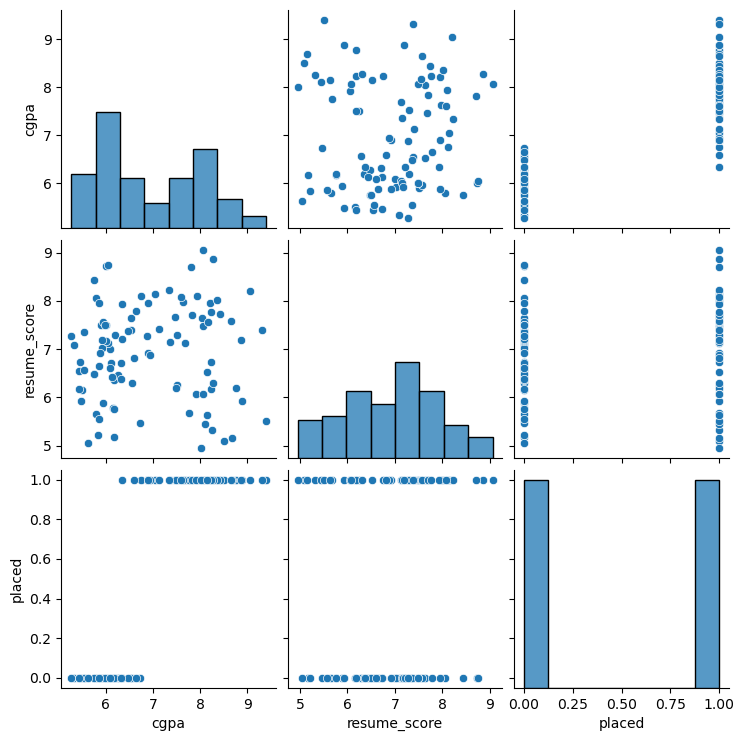

In [4]:
sns.pairplot(df, diag_kind="hist")
plt.show()

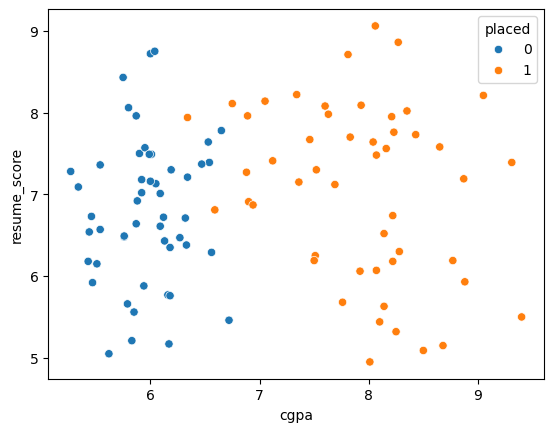

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="cgpa",
    y="resume_score",
    hue="placed"
)

plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
model=Perceptron()
x_train,x_test,y_train,y_test=train_test_split(df[["cgpa","resume_score"]],df["placed"],test_size=0.2,random_state=42)
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 1.0


In [7]:
print(model.coef_,model.intercept_)

[[5.28217372 0.95624355]] [1.]


In [14]:
x_test

array([[ 0.58124801,  1.07571177],
       [-0.84869136,  0.15978875],
       [ 0.1522662 ,  0.40868087],
       [ 1.02810407, -1.55258909],
       [-1.32235878, -1.0747162 ],
       [ 0.4918768 , -0.80591271],
       [-0.70569743, -1.22405148],
       [ 0.7868018 ,  0.69739574],
       [-0.68782318, -0.64662175],
       [ 1.06385255, -0.4773751 ],
       [-0.90231409, -1.11453894],
       [ 0.36675711,  0.14983306],
       [-1.06318227, -0.51719784],
       [ 1.32302907,  0.72726279],
       [-0.98274818, -1.43312087],
       [ 0.50975105,  0.29916834],
       [ 2.18992981, -1.49285498],
       [-0.95593682, -0.0791477 ],
       [-0.76825727,  0.01045347],
       [-0.92018833,  0.02040915]])

In [15]:
def step(x):
    return 1 if x>=0 else 0

for i in range(len(x_test)):
    linear_output=np.dot(x_test[i],model.coef_.T)+model.intercept_
    y_pred=step(linear_output)
    print(f"Predicted: {y_pred}, Actual: {y_test.values[i]}")

Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0


In [10]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

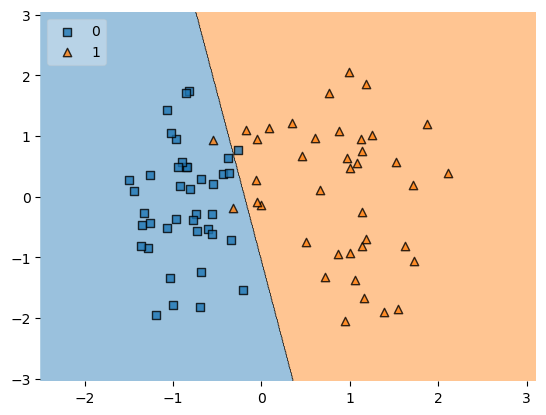

In [13]:
plot_decision_regions(x_train, y_train.values, clf=model, legend=2)